In [250]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.


# XGBoost Standalone Model
Using final_features_1.csv with engineered features optimized for tree-based models

### 1. Load and Prepare Data

In [251]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

# ========== CONFIGURATION: CHANGE THESE VALUES ==========
# Choose which dataset to use: 1, 2, or 3
DATASET_VERSION = 1  # Change this to 2 or 3 to test other feature sets

# Define features for each dataset
FEATURE_CONFIGS = {
    1: {
        'file': '../data/final_features_1.csv',
        'features': [
            "season",
            "platt_apag_mom_pct",
            "platt_crude_mom_pct",
            "temp_avg",
            "precip_avg",
            "threshold_temp_days",
            "threshold_rainy_days",
            "possible_working_days",
            "avg_weight"
        ],
        'name': 'final_features_1.csv'
    },
    2: {
        'file': '../data/final_features_2.csv',
        'features': [
            "quarter",
            "season_sin",
            "season_cos",
            "temp_avg",
            "precip_avg",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight"
        ],
        'name': 'final_features_2.csv'
    },
}
# ========================================================

# Load selected dataset
config = FEATURE_CONFIGS[DATASET_VERSION]
df = pd.read_csv(config['file'])
df["ds"] = pd.to_datetime(df["date"], format="%Y%m") + pd.offsets.MonthEnd(0)
feature_cols = config['features']
dataset_name = config['name']

# Ensure numeric types
for col in feature_cols:
    df[col] = df[col].astype(float)

# Train/validation split (last 32 months for validation)
cutoff = df["ds"].max() - pd.DateOffset(months=32)
df_train = df[df["ds"] <= cutoff].copy()
df_valid = df[df["ds"] > cutoff].copy()

print(f"Using dataset: {dataset_name}")
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"\nTraining set: {len(df_train)} samples ({df_train['ds'].min()} to {df_train['ds'].max()})")
print(f"Validation set: {len(df_valid)} samples ({df_valid['ds'].min()} to {df_valid['ds'].max()})")

Using dataset: final_features_1.csv
Number of features: 9
Features: ['season', 'platt_apag_mom_pct', 'platt_crude_mom_pct', 'temp_avg', 'precip_avg', 'threshold_temp_days', 'threshold_rainy_days', 'possible_working_days', 'avg_weight']

Training set: 264 samples (2001-01-31 00:00:00 to 2022-12-31 00:00:00)
Validation set: 32 samples (2023-01-31 00:00:00 to 2025-08-31 00:00:00)


### 2. Add Simple Time Features

In [252]:
# Extract time features
df_train["year"] = df_train["ds"].dt.year
df_train["month"] = df_train["ds"].dt.month

df_valid["year"] = df_valid["ds"].dt.year
df_valid["month"] = df_valid["ds"].dt.month

# All features: original features + time features
time_features = ['year', 'month']
all_features = feature_cols + time_features

print(f"\nTotal features: {len(all_features)}")
print(f"Feature list: {all_features}")


Total features: 11
Feature list: ['season', 'platt_apag_mom_pct', 'platt_crude_mom_pct', 'temp_avg', 'precip_avg', 'threshold_temp_days', 'threshold_rainy_days', 'possible_working_days', 'avg_weight', 'year', 'month']


### 3. Prepare Data for XGBoost

In [253]:
# Prepare training and validation sets
X_train = df_train[all_features]
y_train = df_train["demand"]

X_valid = df_valid[all_features]
y_valid = df_valid["demand"]

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_valid)}")

Training samples: 264
Validation samples: 32


### 4. Hyperparameter Tuning

In [254]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

# Define parameter distribution for random search
param_distributions = {
    'max_depth': [2, 3, 4, 5, 6], # tree depth
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1, 0.15], # eta: new_prediction = old prediction + (eta  * tree output)
    'n_estimators': [300, 500, 700, 1000], 
    'min_child_weight': [3,5,7,9], # the minimum "sample size" required to make a decision
    'subsample': [0.75, 0.8, 0.85, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0], 
    'gamma': [0, 0.1, 0.2, 0.3, 0.5], # used for pruning: gain - gamma > 0 
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0] # similarity score = (sum of residuals^2) / (number of red. + lambda)
}

# Base model
base_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Random search with cross-validation
# Using 3-fold CV to save time (can increase for more robust results)
print("Starting hyperparameter tuning...")
print("This may take several minutes...\n")

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=100,  # Number of parameter combinations to try
    scoring='neg_mean_squared_error',
    cv=3,  # 3-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the random search
random_search.fit(X_train, y_train)

print("\n" + "="*60)
print("Best Parameters Found:")
print("="*60)
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV Score (negative MSE): {random_search.best_score_:.2f}")
print(f"Best RMSE: {np.sqrt(-random_search.best_score_):,.2f}")

# Store best model
best_model = random_search.best_estimator_

Starting hyperparameter tuning...
This may take several minutes...

Fitting 3 folds for each of 100 candidates, totalling 300 fits

Best Parameters Found:
  subsample: 0.8
  reg_lambda: 2.0
  reg_alpha: 0.1
  n_estimators: 1000
  min_child_weight: 5
  max_depth: 2
  learning_rate: 0.01
  gamma: 0.5
  colsample_bytree: 0.9

Best CV Score (negative MSE): -680289262.70
Best RMSE: 26,082.36


In [255]:
# Optional: Visualize tuning results
results_df = pd.DataFrame(random_search.cv_results_)
results_df['mean_rmse'] = np.sqrt(-results_df['mean_test_score'])
results_df = results_df.sort_values('mean_rmse')

print("\nTop 5 Parameter Combinations:")
print("="*60)
top_5 = results_df.head(5)[['mean_rmse', 'params']]
for idx, row in top_5.iterrows():
    print(f"\nRMSE: {row['mean_rmse']:,.2f}")
    print(f"Params: {row['params']}")


Top 5 Parameter Combinations:

RMSE: 26,082.36
Params: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.9}

RMSE: 26,141.01
Params: {'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}

RMSE: 26,160.56
Params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}

RMSE: 26,169.62
Params: {'subsample': 0.75, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.7}

RMSE: 26,456.11
Params: {'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate'

### 5. Train Final Model with Best Parameters

In [256]:
# Train final model with best parameters and early stopping
model = xgb.XGBRegressor(
    **random_search.best_params_,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

# Train with validation monitoring
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best score: {model.best_score:.4f}")

[0]	validation_0-rmse:50825.38291	validation_1-rmse:47733.25894
[50]	validation_0-rmse:37259.95343	validation_1-rmse:36605.73528
[100]	validation_0-rmse:30057.01830	validation_1-rmse:30976.44111
[150]	validation_0-rmse:26248.41426	validation_1-rmse:27304.11331
[200]	validation_0-rmse:24104.33845	validation_1-rmse:25148.15210
[250]	validation_0-rmse:22790.17939	validation_1-rmse:23841.16124
[300]	validation_0-rmse:21834.24410	validation_1-rmse:22837.13960
[350]	validation_0-rmse:21111.25431	validation_1-rmse:21767.10096
[400]	validation_0-rmse:20519.87529	validation_1-rmse:20967.59663
[450]	validation_0-rmse:20005.51281	validation_1-rmse:20400.63271
[500]	validation_0-rmse:19561.86821	validation_1-rmse:20092.48233
[550]	validation_0-rmse:19180.87634	validation_1-rmse:20026.51599
[600]	validation_0-rmse:18812.03678	validation_1-rmse:19873.37109
[650]	validation_0-rmse:18466.46562	validation_1-rmse:19808.08985
[700]	validation_0-rmse:18169.70966	validation_1-rmse:19807.74220
[726]	validat

### 6. Make Predictions and Evaluate

In [257]:
# Predictions
train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

# Calculate metrics
def calculate_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100
    
    print(f"\n{label} Metrics:")
    print(f"  RMSE:  {rmse:,.1f}")
    print(f"  MAE:   {mae:,.1f}")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  RMSPE: {rmspe:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'rmspe': rmspe}

train_metrics = calculate_metrics(y_train, train_pred, "Training")
valid_metrics = calculate_metrics(y_valid, valid_pred, "Validation")

# Save results to JSON with auto-increment to avoid overwriting
import json
from datetime import datetime
import glob
import re

# Get current hyperparameters
current_params = random_search.best_params_

# Find existing result files for this dataset
existing_files = glob.glob(f"../results/xgboost_feature{DATASET_VERSION}_results_*.json")

# Check if these hyperparameters already exist
params_exist = False
existing_run = None

for file in existing_files:
    try:
        with open(file, 'r') as f:
            existing_data = json.load(f)
            if existing_data.get('best_parameters') == current_params:
                params_exist = True
                existing_run = file
                break
    except:
        continue

if params_exist:
    print("\n" + "="*60)
    print("⚠️  RESULTS NOT SAVED")
    print("="*60)
    print(f"These hyperparameters already exist in: {existing_run}")
    print("\nCurrent parameters:")
    for param, value in current_params.items():
        print(f"  {param}: {value}")
    print("\nTo save anyway, delete the existing file or change hyperparameters.")
    print("="*60)
else:
    # Extract run numbers for new file
    run_numbers = []
    for file in existing_files:
        match = re.search(rf'xgboost_feature{DATASET_VERSION}_results_(\d+)\.json', file)
        if match:
            run_numbers.append(int(match.group(1)))

    # Determine next run number
    if run_numbers:
        next_run = max(run_numbers) + 1
    else:
        next_run = 1

    # Create results dictionary
    results = {
        "model_name": f"XGBoost Standalone - {dataset_name}",
        "run_number": next_run,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "dataset": dataset_name,
        "features": all_features,
        "num_features": len(all_features),
        "train_samples": len(X_train),
        "valid_samples": len(X_valid),
        "best_parameters": current_params,
        "hyperparameter_tuning": {
            "method": "RandomizedSearchCV",
            "n_iterations": 50,
            "cv_folds": 3,
            "best_cv_score": float(random_search.best_score_)
        },
        "metrics": {
            "training": {
                "rmse": float(train_metrics['rmse']),
                "mae": float(train_metrics['mae']),
                "mape": float(train_metrics['mape']),
                "rmspe": float(train_metrics['rmspe'])
            },
            "validation": {
                "rmse": float(valid_metrics['rmse']),
                "mae": float(valid_metrics['mae']),
                "mape": float(valid_metrics['mape']),
                "rmspe": float(valid_metrics['rmspe'])
            }
        }
    }

    # Save to file with run number
    result_filename = f"xgboost_feature{DATASET_VERSION}_results_{next_run}.json"
    result_path = f"../results/{result_filename}"

    with open(result_path, 'w') as f:
        json.dump(results, f, indent=2)

    print("\n" + "="*60)
    print(f"✅ Results saved to: {result_path}")
    print(f"Run number: {next_run}")
    print("="*60)


Training Metrics:
  RMSE:  18,305.6
  MAE:   14,131.2
  MAPE:  11.91%
  RMSPE: 18.43%

Validation Metrics:
  RMSE:  19,755.9
  MAE:   16,184.0
  MAPE:  17.43%
  RMSPE: 24.21%

⚠️  RESULTS NOT SAVED
These hyperparameters already exist in: ../results/xgboost_feature1_results_2.json

Current parameters:
  subsample: 0.8
  reg_lambda: 2.0
  reg_alpha: 0.1
  n_estimators: 1000
  min_child_weight: 5
  max_depth: 2
  learning_rate: 0.01
  gamma: 0.5
  colsample_bytree: 0.9

To save anyway, delete the existing file or change hyperparameters.


### 7. Feature Importance Analysis


Top 10 Most Important Features:
                  feature  importance
8              avg_weight    0.364262
10                  month    0.179620
0                  season    0.145670
6    threshold_rainy_days    0.079319
3                temp_avg    0.071602
4              precip_avg    0.036471
9                    year    0.032231
7   possible_working_days    0.031385
5     threshold_temp_days    0.022256
1      platt_apag_mom_pct    0.020017


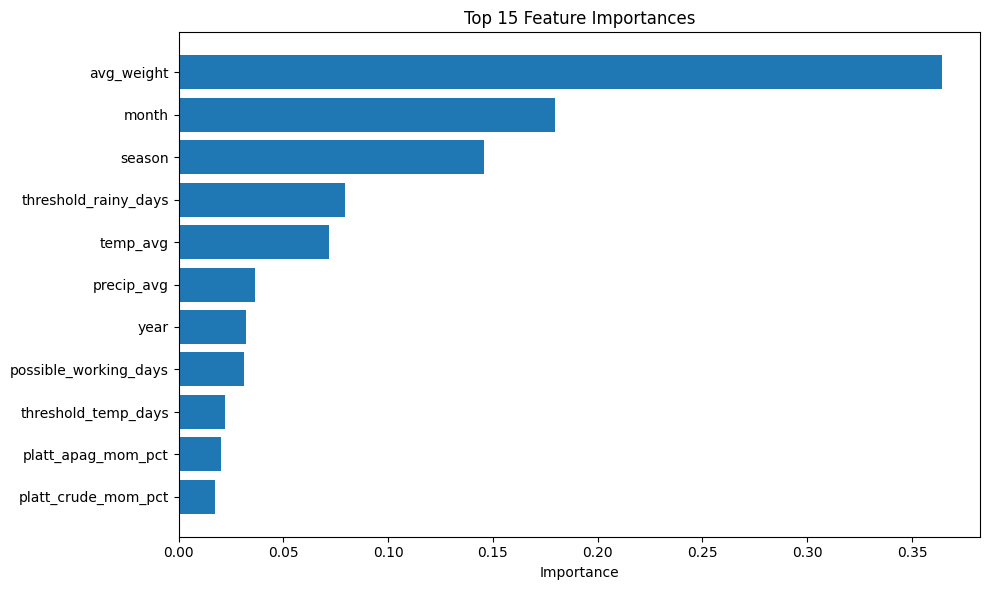

In [258]:
# Get feature importance
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(15), feature_importance['importance'].head(15))
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 7.5. Visualize Decision Trees (Optional)

/Users/chungsangyoon/Desktop/Playground/ml_project/.venv/lib/python3.13/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


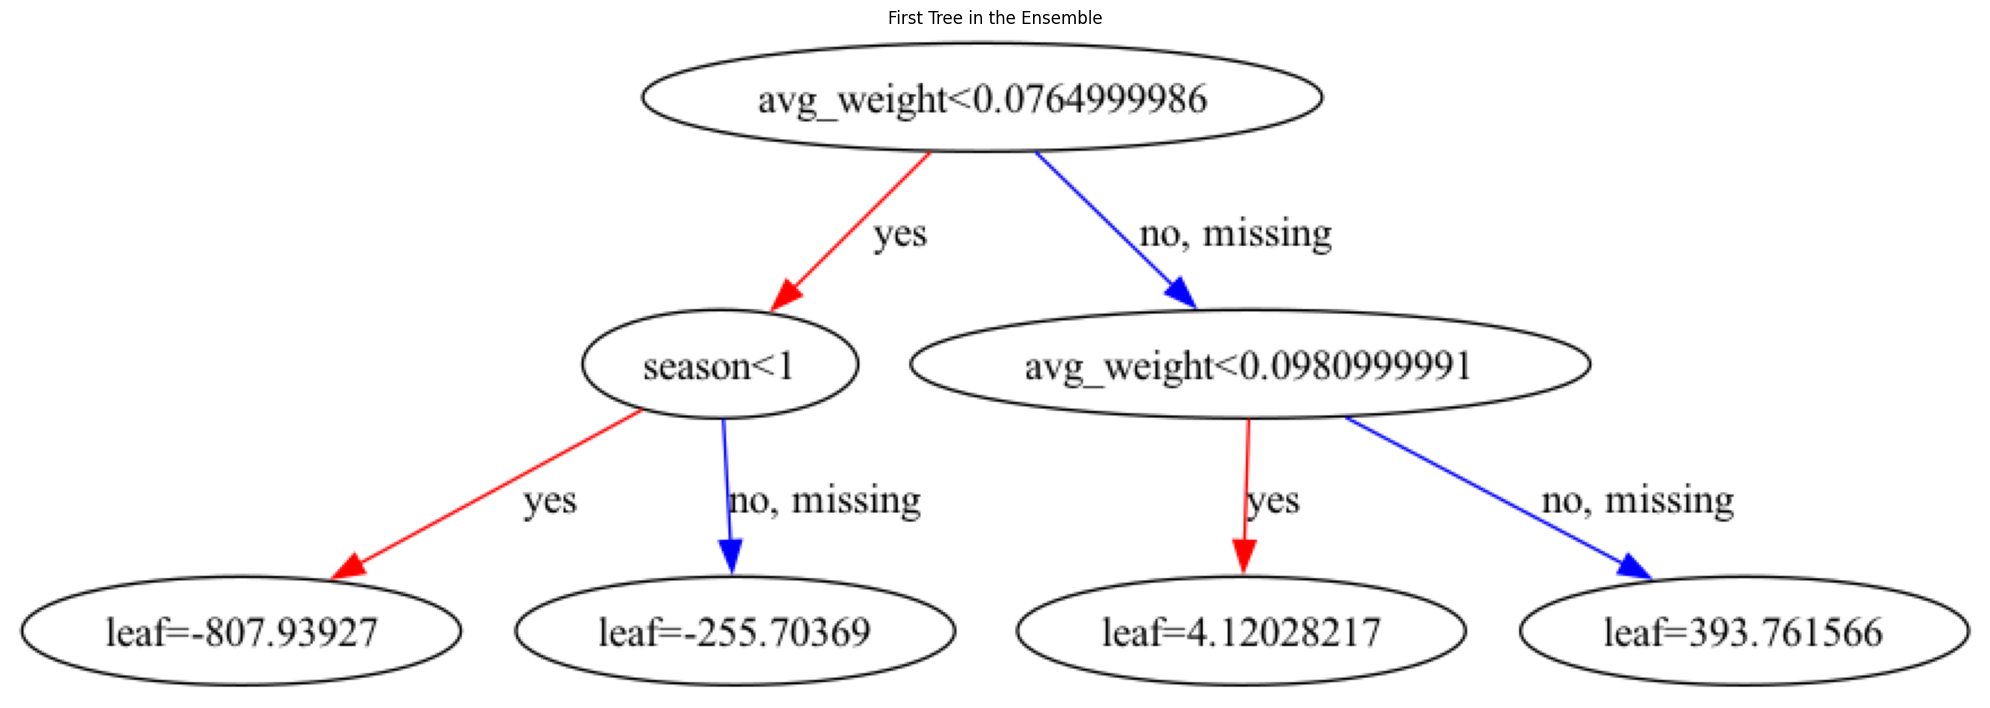

/Users/chungsangyoon/Desktop/Playground/ml_project/.venv/lib/python3.13/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


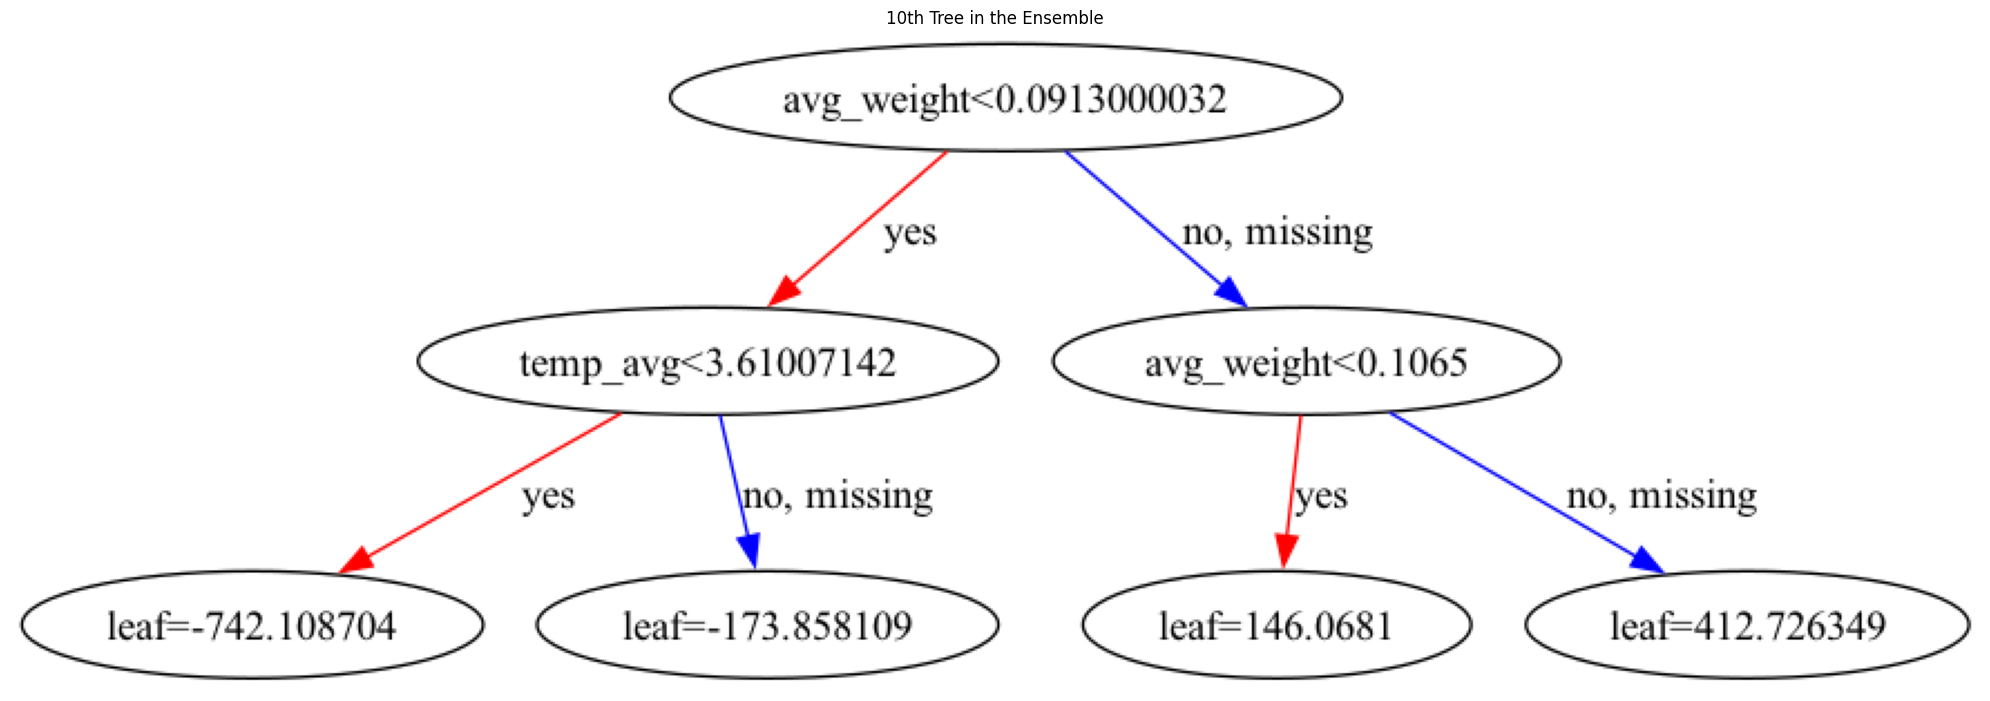

In [259]:
# Visualize individual trees from the model

# Method 1: Using xgboost's plot_tree (simple, built-in)
import matplotlib.pyplot as plt
import graphviz

# Plot the first tree (tree 0)
fig, ax = plt.subplots(figsize=(20, 10))
xgb.plot_tree(model, num_trees=0, ax=ax)
plt.title("First Tree in the Ensemble")
plt.tight_layout()
plt.show()

# Plot the 10th tree
fig, ax = plt.subplots(figsize=(20, 10))
xgb.plot_tree(model, num_trees=9, ax=ax)  # 0-indexed, so 9 = 10th tree
plt.title("10th Tree in the Ensemble")
plt.tight_layout()
plt.show()

/Users/chungsangyoon/Desktop/Playground/ml_project/.venv/lib/python3.13/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


First tree visualization (Graphviz):


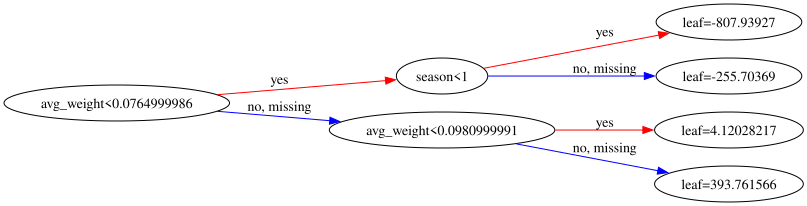

In [260]:
# Method 2: Using Graphviz for nicer visualization (if installed)
# Note: Requires graphviz to be installed: pip install graphviz

try:
    import graphviz
    
    # Export tree to graphviz format
    graph = xgb.to_graphviz(model, num_trees=0, rankdir='LR')
    
    # Display inline (in Jupyter)
    print("First tree visualization (Graphviz):")
    display(graph)
    
    # You can also save it
    # graph.render("tree_0", format="png")
    
except ImportError:
    print("Graphviz not installed. Using matplotlib plot_tree instead.")
    print("To install: pip install graphviz")
    print("(Also need system graphviz: brew install graphviz on Mac)")
    
    # Fallback to matplotlib
    fig, ax = plt.subplots(figsize=(20, 10))
    xgb.plot_tree(model, num_trees=0, ax=ax)
    plt.title("First Tree (matplotlib fallback)")
    plt.tight_layout()
    plt.show()

In [261]:
# Export tree structure to text for inspection
print("\n" + "="*60)
print("Tree Structure Information")
print("="*60)
print(f"Total number of trees in model: {model.n_estimators}")
print(f"Trees actually used (with early stopping): {model.best_iteration + 1}")
print(f"Max depth configured: {model.max_depth}")

# Get feature names used in first tree
booster = model.get_booster()
tree_dump = booster.get_dump(dump_format='text')

print(f"\nFirst tree structure (first 20 lines):")
print("="*60)
for line in tree_dump[0].split('\n')[:20]:
    print(line)


Tree Structure Information
Total number of trees in model: 1000
Trees actually used (with early stopping): 678
Max depth configured: 2

First tree structure (first 20 lines):
0:[avg_weight<0.0764999986] yes=1,no=2,missing=2
	1:[season<1] yes=3,no=4,missing=4
		3:leaf=-807.93927
		4:leaf=-255.70369
	2:[avg_weight<0.0980999991] yes=5,no=6,missing=6
		5:leaf=4.12028217
		6:leaf=393.761566



### 8. Visualize Predictions

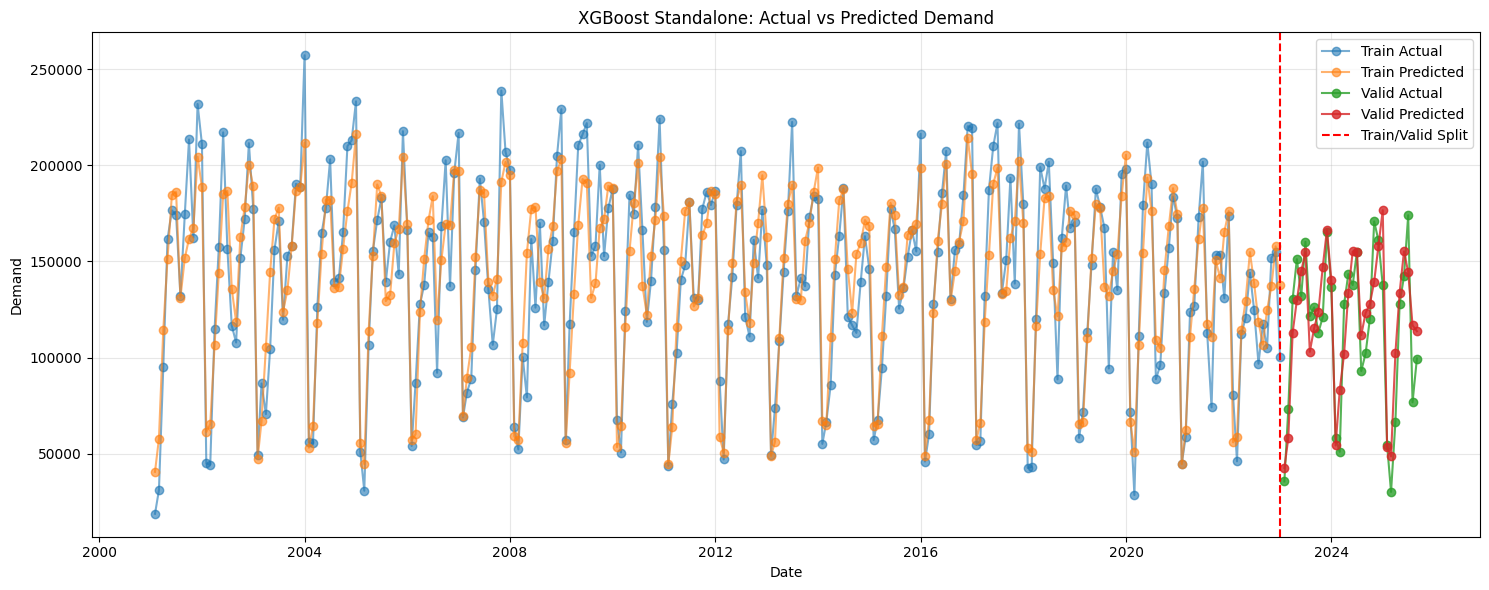

In [262]:
# Create visualization dataframe
viz_train = df_train.copy()
viz_train['prediction'] = train_pred
viz_train['set'] = 'train'

viz_valid = df_valid.copy()
viz_valid['prediction'] = valid_pred
viz_valid['set'] = 'valid'

viz = pd.concat([viz_train, viz_valid])

# Plot
plt.figure(figsize=(15, 6))
plt.plot(viz_train['ds'], viz_train['demand'], 'o-', label='Train Actual', alpha=0.6)
plt.plot(viz_train['ds'], viz_train['prediction'], 'o-', label='Train Predicted', alpha=0.6)
plt.plot(viz_valid['ds'], viz_valid['demand'], 'o-', label='Valid Actual', alpha=0.8)
plt.plot(viz_valid['ds'], viz_valid['prediction'], 'o-', label='Valid Predicted', alpha=0.8)
plt.axvline(x=cutoff, color='red', linestyle='--', label='Train/Valid Split')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('XGBoost Standalone: Actual vs Predicted Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Save Model (Optional)

In [263]:
# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

# Save the model
model.save_model('../models/xgboost_standalone.json')
print("Model saved to ../models/xgboost_standalone.json")

# To load later:
# loaded_model = xgb.XGBRegressor()
# loaded_model.load_model('../models/xgboost_standalone.json')

Model saved to ../models/xgboost_standalone.json


### 10. Compare Results (Optional)

In [264]:
# Compare results from different feature sets
import glob

# Load all result files
result_files = glob.glob('../results/xgboost_*.json')

if len(result_files) > 0:
    comparison = []
    
    for file_path in result_files:
        with open(file_path, 'r') as f:
            data = json.load(f)
            comparison.append({
                'Model': data['model_name'],
                'Dataset': data['dataset'],
                'Features': data['num_features'],
                'Train RMSE': data['metrics']['training']['rmse'],
                'Valid RMSE': data['metrics']['validation']['rmse'],
                'Train MAPE': data['metrics']['training']['mape'],
                'Valid MAPE': data['metrics']['validation']['mape'],
                'Timestamp': data['timestamp']
            })
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame(comparison)
    comparison_df = comparison_df.sort_values('Valid RMSE')
    
    print("Model Comparison:")
    print("="*80)
    print(comparison_df.to_string(index=False))
    print("\n" + "="*80)
    print(f"Best model: {comparison_df.iloc[0]['Model']}")
    print(f"Best Validation RMSE: {comparison_df.iloc[0]['Valid RMSE']:,.1f}")
else:
    print("No result files found yet. Run the notebook to generate results.")

Model Comparison:
                                    Model              Dataset  Features   Train RMSE   Valid RMSE  Train MAPE  Valid MAPE           Timestamp
XGBoost Standalone - final_features_1.csv final_features_1.csv        11 18305.553546 19755.910987   11.913760   17.433627 2025-12-05 15:52:50
XGBoost Standalone - final_features_2.csv final_features_2.csv        11 20022.473467 20439.172246   13.348167   19.393615 2025-12-05 15:52:18
XGBoost Standalone - final_features_1.csv final_features_1.csv        11 16707.996923 21174.658654   11.519822   21.382602 2025-12-04 21:26:10

Best model: XGBoost Standalone - final_features_1.csv
Best Validation RMSE: 19,755.9
